### In this script, DBN is run on the all the sessions
### In this script, DBN is run with 1s time bin, 3 time lag 
### In this script, the animal tracking is done with only one camera - camera 2 (middle) 
### This script specifically summarized the DBN related results
#### this script focuses on the summarizing results pooling all six (five in reality, kanga is shared) animals (three dyads); it can only be run after the "3LagDBN_and_bhv_singlecam_wholebodylabels_allsessions_basicEvents"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn
import scipy
import scipy.stats as st
from sklearn.neighbors import KernelDensity
from sklearn.linear_model import LinearRegression
import string
import warnings
import pickle

import os
import glob
import random
from time import time

from pgmpy.models import BayesianModel
from pgmpy.models import DynamicBayesianNetwork as DBN
from pgmpy.estimators import BayesianEstimator
from pgmpy.estimators import HillClimbSearch,BicScore
from pgmpy.base import DAG
import networkx as nx


### function - get body part location for each pair of cameras

In [2]:
from ana_functions.body_part_locs_eachpair import body_part_locs_eachpair
from ana_functions.body_part_locs_singlecam import body_part_locs_singlecam

### function - align the two cameras

In [3]:
from ana_functions.camera_align import camera_align       

### function - merge the two pairs of cameras

In [4]:
from ana_functions.camera_merge import camera_merge

### function - find social gaze time point

In [5]:
from ana_functions.find_socialgaze_timepoint import find_socialgaze_timepoint
from ana_functions.find_socialgaze_timepoint_singlecam import find_socialgaze_timepoint_singlecam
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody import find_socialgaze_timepoint_singlecam_wholebody

### function - define time point of behavioral events

In [6]:
from ana_functions.bhv_events_timepoint import bhv_events_timepoint
from ana_functions.bhv_events_timepoint_singlecam import bhv_events_timepoint_singlecam

### function - plot behavioral events

In [7]:
from ana_functions.plot_bhv_events import plot_bhv_events
from ana_functions.plot_bhv_events_levertube import plot_bhv_events_levertube
from ana_functions.draw_self_loop import draw_self_loop
import matplotlib.patches as mpatches 
from matplotlib.collections import PatchCollection

### function - plot inter-pull interval

In [8]:
from ana_functions.plot_interpull_interval import plot_interpull_interval

### function - make demo videos with skeleton and inportant vectors

In [9]:
from ana_functions.tracking_video_singlecam_demo import tracking_video_singlecam_demo
from ana_functions.tracking_video_singlecam_wholebody_demo import tracking_video_singlecam_wholebody_demo

### function - interval between all behavioral events

In [10]:
from ana_functions.bhv_events_interval import bhv_events_interval

### function - train the dynamic bayesian network - multi time lag (3 lags)

In [11]:
from ana_functions.train_DBN_multiLag import train_DBN_multiLag
from ana_functions.train_DBN_multiLag import train_DBN_multiLag_create_df_only
from ana_functions.train_DBN_multiLag import train_DBN_multiLag_training_only
from ana_functions.train_DBN_multiLag import graph_to_matrix
from ana_functions.train_DBN_multiLag import get_weighted_dags
from ana_functions.train_DBN_multiLag import get_significant_edges
from ana_functions.train_DBN_multiLag import threshold_edges
from ana_functions.train_DBN_multiLag import Modulation_Index
from ana_functions.EfficientTimeShuffling import EfficientShuffle
from ana_functions.AicScore import AicScore

## Analyze each session

### prepare the basic behavioral data (especially the time stamps for each bhv events)
### separate each session based on trial types (different force levels)

In [12]:
# instead of using gaze angle threshold, use the target rectagon to deside gaze info
# ...need to update
sqr_thres_tubelever = 75 # draw the square around tube and lever
sqr_thres_face = 1.15 # a ratio for defining face boundary
sqr_thres_body = 4 # how many times to enlongate the face box boundry to the body


# get the fps of the analyzed video
fps = 30

# frame number of the demo video
# nframes = 0.5*30 # second*30fps
nframes = 1*30 # second*30fps

# re-analyze the video or not
reanalyze_video = 0
redo_anystep = 0

# only analyze the best (five) sessions for each conditions
do_bestsession = 1
if do_bestsession:
    savefile_sufix = '_bestsessions'
else:
    savefile_sufix = '_allsessions'
    

# force manipulation type
# SR_bothchange: self reward, both forces changed
# CO_bothchange: 1s cooperation, both forces changed
# CO_A1change: 1s cooperation, animal 1 forces changed
# CO_A2change: 1s cooperation, animal 2 forces changed
forceManiTypes = ['SR_bothchange','CO_A1change','CO_A2change',]
nforceManiTypes = np.shape(forceManiTypes)[0]

#  
animal1_fixedorders = ['koala', 'dannon', 'dodson']
animal2_fixedorders = ['vermelho', 'kanga', 'kanga' ]

animal1_filenames = ["Koala","Dannon","Dodson"]
animal2_filenames = ["Vermelho","Kanga","Kanga"]

nanimalpairs = np.shape(animal1_fixedorders)[0]


# video tracking results info
animalnames_videotrack = ['dodson','scorch'] # does not really mean dodson and scorch, instead, indicate animal1 and animal2
bodypartnames_videotrack = ['rightTuft','whiteBlaze','leftTuft','rightEye','leftEye','mouth']


# which camera to analyzed
cameraID = 'camera-2'
cameraID_short = 'cam2'


# location of levers and tubes for camera 2
# get this information using DLC animal tracking GUI, the results are stored: 
# /home/ws523/marmoset_tracking_DLCv2/marmoset_tracking_with_lever_tube-weikang-2023-04-13/labeled-data/
considerlevertube = 1
considertubeonly = 0
# # camera 1
# lever_locs_camI = {'dodson':np.array([645,600]),'scorch':np.array([425,435])}
# tube_locs_camI  = {'dodson':np.array([1350,630]),'scorch':np.array([555,345])}
# # camera 2
lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
tube_locs_camI  = {'dodson':np.array([1550,515]),'scorch':np.array([350,515])}
# # lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
# # tube_locs_camI  = {'dodson':np.array([1650,490]),'scorch':np.array([250,490])}
# # camera 3
# lever_locs_camI = {'dodson':np.array([1580,440]),'scorch':np.array([1296,540])}
# tube_locs_camI  = {'dodson':np.array([1470,375]),'scorch':np.array([805,475])}


# where to save the summarizing data
data_saved_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_forceManipulation_task_data_saved/'


    

In [13]:
# define variables for looking at specific data set

# load the data for plot
mergetempRos = 0
doBhvitv_timebin = 0

moreSampSize = 0
minmaxfullSampSize = 1
samplingsize_name = 'full_row_number'

temp_resolu = 1 # temporal resolution - 1s

# DBN weight, define which time lag to look at
# make sure the to nodes are the targeted animal
doconsiderSigEdge = 0

# modulation index between first block and others
doMI_firstblock = 0
# modulation index between previous block and others
doMI_preblock = 1


pull_pull_fromNodes_all = [[1,5,9],[0,4,8]]
pull_pull_toNodes_all = [[0,0,0],[1,1,1]]
#
gaze_gaze_fromNodes_all = [[3,7,11],[2,6,10]]
gaze_gaze_toNodes_all = [[2,2,2],[3,3,3]]
#
within_pullgaze_fromNodes_all = [[0,4,8],[1,5,9]]
within_pullgaze_toNodes_all = [[2,2,2],[3,3,3]]
#
across_pullgaze_fromNodes_all = [[1,5,9],[0,4,8]]
across_pullgaze_toNodes_all = [[2,2,2],[3,3,3]]
#
within_gazepull_fromNodes_all = [[2,6,10],[3,7,11]]
within_gazepull_toNodes_all = [[0,0,0],[1,1,1]]
#
across_gazepull_fromNodes_all = [[3,7,11],[2,6,10]]
across_gazepull_toNodes_all = [[0,0,0],[1,1,1]]




In [14]:
# load data for all animals
summary_all_results = pd.DataFrame(columns=['date','forceContType','self_animal','partner_animal','subblockID',
                                            'self_force','partner_force','trialnum','blocktime',
                                            'succ_rate','gaze_number','pull_number',
                                            'pull_pull_weight','gaze_gaze_weight','within_pullgaze_weight',
                                            'across_pullgaze_weight','within_gazepull_weight','across_gazepull_weight',
                                           ])


#
for ianimalpair in np.arange(0,nanimalpairs,1):
    
    animal1_fixedorder = [animal1_fixedorders[ianimalpair]]
    animal2_fixedorder = [animal2_fixedorders[ianimalpair]]
    
    animal1_filename = animal1_filenames[ianimalpair]
    animal2_filename = animal2_filenames[ianimalpair]
    
    # load data for all manipulation types
    for iforceManiType in np.arange(0,nforceManiTypes,1):
        
        forceManiType = forceManiTypes[iforceManiType]       
    
        # load saved data
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorder[0]+animal2_fixedorder[0]+'/'

        with open(data_saved_subfolder+'/animal1_name_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            animal1_name_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/animal2_name_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            animal2_name_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/trialdates_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            trialdates_all_dates = pickle.load(f)

        with open(data_saved_subfolder+'/force1_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            force1_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/force2_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            force2_all_dates = pickle.load(f)

        with open(data_saved_subfolder+'/subblockID_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            subblockID_all_dates = pickle.load(f)

        with open(data_saved_subfolder+'/succ_rate_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            succ_rate_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/trialnum_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            trialnum_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/blocktime_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            blocktime_all_dates = pickle.load(f)

        with open(data_saved_subfolder+'/owgaze1_num_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            owgaze1_num_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/owgaze2_num_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            owgaze2_num_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/mtgaze1_num_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            mtgaze1_num_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/mtgaze2_num_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            mtgaze2_num_all_dates = pickle.load(f)     
        with open(data_saved_subfolder+'/pull1_num_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            pull1_num_all_dates = pickle.load(f)
        with open(data_saved_subfolder+'/pull2_num_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            pull2_num_all_dates = pickle.load(f)

        with open(data_saved_subfolder+'/cross_corr_bhv_all_dates_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'.pkl', 'rb') as f:
            cross_corr_bhv_all_dates = pickle.load(f)
            
        # load the DBN related data
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_allsessions'+savefile_sufix+'_3lags/'+cameraID+'/'+animal1_fixedorder[0]+animal2_fixedorder[0]+'/'

        if moreSampSize:
            with open(data_saved_subfolder+'/DAGscores_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_moreSampSize.pkl', 'rb') as f:
                DAGscores_diffTempRo_diffSampSize = pickle.load(f) 
            with open(data_saved_subfolder+'/DAGscores_shuffled_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_moreSampSize.pkl', 'rb') as f:
                DAGscores_shuffled_diffTempRo_diffSampSize = pickle.load(f) 
            with open(data_saved_subfolder+'/weighted_graphs_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_moreSampSize.pkl', 'rb') as f:
                weighted_graphs_diffTempRo_diffSampSize = pickle.load(f)
            with open(data_saved_subfolder+'/weighted_graphs_shuffled_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_moreSampSize.pkl', 'rb') as f:
                weighted_graphs_shuffled_diffTempRo_diffSampSize = pickle.load(f)
            with open(data_saved_subfolder+'/sig_edges_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_moreSampSize.pkl', 'rb') as f:
                sig_edges_diffTempRo_diffSampSize = pickle.load(f)

        if minmaxfullSampSize:
            with open(data_saved_subfolder+'/DAGscores_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_minmaxfullSampSize.pkl', 'rb') as f:
                DAGscores_diffTempRo_diffSampSize = pickle.load(f) 
            with open(data_saved_subfolder+'/DAGscores_shuffled_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_minmaxfullSampSize.pkl', 'rb') as f:
                DAGscores_shuffled_diffTempRo_diffSampSize = pickle.load(f) 
            with open(data_saved_subfolder+'/weighted_graphs_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_minmaxfullSampSize.pkl', 'rb') as f:
                weighted_graphs_diffTempRo_diffSampSize = pickle.load(f)
            with open(data_saved_subfolder+'/weighted_graphs_shuffled_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_minmaxfullSampSize.pkl', 'rb') as f:
                weighted_graphs_shuffled_diffTempRo_diffSampSize = pickle.load(f)
            with open(data_saved_subfolder+'/sig_edges_diffTempRo_diffSampSize_'+animal1_fixedorder[0]+animal2_fixedorder[0]+'_'+forceManiType+'_minmaxfullSampSize.pkl', 'rb') as f:
                sig_edges_diffTempRo_diffSampSize = pickle.load(f)

        print('all data are loaded:'+animal1_fixedorder[0]+' '+animal2_fixedorder[0]+' '+forceManiType)

        # get the force for the first block of each session
        #
        # Identify unique trial dates and their first occurrence indices
        unique_dates, first_indices = np.unique(trialdates_all_dates, return_index=True)
        # Filter for first block (subblockID = 0)
        first_block_indices = first_indices[subblockID_all_dates[first_indices] == 0]
        # force 1
        # Map the trial date to the first block's force1 value
        first_block_force_map = {trialdates_all_dates[i]: force1_all_dates[i] for i in first_block_indices}
        # Create the new array by mapping each trialdate to its first block's force1 value
        force1_firstblock_all_dates = np.array([first_block_force_map[date] for date in trialdates_all_dates])
        # force 2
        # Map the trial date to the first block's force2 value
        first_block_force_map = {trialdates_all_dates[i]: force2_all_dates[i] for i in first_block_indices}
        # Create the new array by mapping each trialdate to its first block's force2 value
        force2_firstblock_all_dates = np.array([first_block_force_map[date] for date in trialdates_all_dates])

        # get the force for the previous block of each session
        #
        # force 1
        # Initialize the output array with NaNs (same size as force1_all_dates)
        force1_preblock_all_dates = np.full_like(force1_all_dates, np.nan)
        # Iterate through the array
        for i in range(1, len(force1_all_dates)):
            # Check if the current trial date is the same as the previous one
            if trialdates_all_dates[i] == trialdates_all_dates[i - 1]:
                # Assign the force2 value from the previous block
                force1_preblock_all_dates[i] = force1_all_dates[i - 1]
            else:
                # If it's the first block of a new trial date, use the same value
                force1_preblock_all_dates[i] = force1_all_dates[i]
        # The first value for the array should match itself (no previous block)
        force1_preblock_all_dates[0] = force1_all_dates[0]
        # force 2
        # Initialize the output array with NaNs (same size as force2_all_dates)
        force2_preblock_all_dates = np.full_like(force2_all_dates, np.nan)
        # Iterate through the array
        for i in range(1, len(force2_all_dates)):
            # Check if the current trial date is the same as the previous one
            if trialdates_all_dates[i] == trialdates_all_dates[i - 1]:
                # Assign the force2 value from the previous block
                force2_preblock_all_dates[i] = force2_all_dates[i - 1]
            else:
                # If it's the first block of a new trial date, use the same value
                force2_preblock_all_dates[i] = force2_all_dates[i]
        # The first value for the array should match itself (no previous block)
        force2_preblock_all_dates[0] = force2_all_dates[0]
        
        # 
        ndates = np.shape(trialdates_all_dates)[0]
        
        for idate in np.arange(0,ndates,1):
            
            idate_name = trialdates_all_dates[idate]
            idate_blockID = subblockID_all_dates[idate]
            
            forcecombined = str(int(force1_all_dates[idate]))+'&'+str(int(force2_all_dates[idate]))

            if forceManiType == 'SR_bothchange':
                animal1_forceContType = 'self_change_SR'
                animal2_forceContType = 'self_change_SR'
            elif forceManiType == 'CO_A1change':
                animal1_forceContType = 'self_change_MC'
                animal2_forceContType = 'partner_change_MC'
            elif forceManiType == 'CO_A2change':
                animal1_forceContType = 'partner_change_MC'
                animal2_forceContType = 'self_change_MC'
            else:
                animal1_forceContType = None
                animal2_forceContType = None
             
            # get the dbn matrix
            if (~doMI_firstblock==1) & (~doMI_preblock==1):
                weighted_graphs = weighted_graphs_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined]
                weighted_shaffle_graphs = weighted_graphs_shuffled_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined]
                sig_edges = sig_edges_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined]
                #
                sig_edges[sig_edges==0]=np.nan
                
            # modulation index comparing the first block
            elif doMI_firstblock | doMI_preblock:
                
                if doMI_firstblock:
                    forcecombined_base = str(int(force1_firstblock_all_dates[idate]))+'&'+str(int(force2_firstblock_all_dates[idate]))
                elif doMI_preblock:
                    forcecombined_base = str(int(force1_preblock_all_dates[idate]))+'&'+str(int(force2_preblock_all_dates[idate]))
                
                #
                weighted_graphs_base = weighted_graphs_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined_base]
                weighted_shaffle_graphs_base = weighted_graphs_shuffled_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined_base]
                sig_edges_base = sig_edges_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined_base]
                
                weighted_graphs_tgt = weighted_graphs_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined]
                weighted_shaffle_graphs_tgt = weighted_graphs_shuffled_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined]
                sig_edges_tgt = sig_edges_diffTempRo_diffSampSize[(str(temp_resolu),samplingsize_name)][idate_name][forcecombined]
                
                nMIbootstraps = 100
                weighted_graphs, sig_edges = Modulation_Index(weighted_graphs_base, weighted_graphs_tgt,
                                                      sig_edges_base, sig_edges_tgt, nMIbootstraps)
                #
                sig_edges = sig_edges.astype(float)
                sig_edges[sig_edges==0]=np.nan
                #
                # remove the first block
                if forcecombined_base == forcecombined:
                    firstblock_edges = np.ones(np.shape(sig_edges))*np.nan
                    weighted_graphs = weighted_graphs* firstblock_edges
            
            # 
            if doconsiderSigEdge:
                weighted_graphs = weighted_graphs * sig_edges
                weighted_shaffle_graphs = weighted_shaffle_graphs * sig_edges
                    
            
            # change kanga's name if partner is dodson
            if animal1_fixedorder[0] == 'dodson':
                animal2_fixedorder[0] = 'kanga_withDo'
            elif animal2_fixedorder[0] == 'dodson':
                animal1_fixedorder[0] = 'kanga_withDo'
                
            # for animal1
            summary_all_results = summary_all_results.append({
                                                        'date': trialdates_all_dates[idate],
                                                        'forceContType':animal1_forceContType,
                                                        'self_animal': animal1_fixedorder[0],
                                                        'partner_animal': animal2_fixedorder[0],
                                                        'subblockID': subblockID_all_dates[idate],
                                                        'self_force': force1_all_dates[idate],
                                                        'partner_force': force2_all_dates[idate],
                                                        'trialnum': trialnum_all_dates[idate],
                                                        'blocktime': blocktime_all_dates[idate],
                                                        'succ_rate': succ_rate_all_dates[idate],
                                                        'gaze_number': owgaze1_num_all_dates[idate]+mtgaze1_num_all_dates[idate],
                                                        'pull_number': pull1_num_all_dates[idate],
                                                        
                                                        'pull_pull_weight':weighted_graphs[:,pull_pull_fromNodes_all[0],pull_pull_toNodes_all[0]].T,
                                                        'gaze_gaze_weight':weighted_graphs[:,gaze_gaze_fromNodes_all[0],gaze_gaze_toNodes_all[0]].T,
                                                        'within_pullgaze_weight':weighted_graphs[:,within_pullgaze_fromNodes_all[0],within_pullgaze_toNodes_all[0]].T,
                                                        'across_pullgaze_weight':weighted_graphs[:,across_pullgaze_fromNodes_all[0],across_pullgaze_toNodes_all[0]].T,
                                                        'within_gazepull_weight':weighted_graphs[:,within_gazepull_fromNodes_all[0],within_gazepull_toNodes_all[0]].T,
                                                        'across_gazepull_weight':weighted_graphs[:,across_gazepull_fromNodes_all[0],across_gazepull_toNodes_all[0]].T,
                                                    }, ignore_index=True)
            
            # for animal2            
            summary_all_results = summary_all_results.append({
                                                        'date': trialdates_all_dates[idate],
                                                        'forceContType':animal2_forceContType,
                                                        'self_animal': animal2_fixedorder[0],
                                                        'partner_animal': animal1_fixedorder[0],
                                                        'subblockID': subblockID_all_dates[idate],
                                                        'self_force': force2_all_dates[idate],
                                                        'partner_force': force1_all_dates[idate],
                                                        'trialnum': trialnum_all_dates[idate],
                                                        'blocktime': blocktime_all_dates[idate],
                                                        'succ_rate': succ_rate_all_dates[idate],
                                                        'gaze_number': owgaze2_num_all_dates[idate]+mtgaze2_num_all_dates[idate],
                                                        'pull_number': pull2_num_all_dates[idate],
                
                                                        'pull_pull_weight':weighted_graphs[:,pull_pull_fromNodes_all[1],pull_pull_toNodes_all[1]].T,
                                                        'gaze_gaze_weight':weighted_graphs[:,gaze_gaze_fromNodes_all[1],gaze_gaze_toNodes_all[1]].T,
                                                        'within_pullgaze_weight':weighted_graphs[:,within_pullgaze_fromNodes_all[1],within_pullgaze_toNodes_all[1]].T,
                                                        'across_pullgaze_weight':weighted_graphs[:,across_pullgaze_fromNodes_all[1],across_pullgaze_toNodes_all[1]].T,
                                                        'within_gazepull_weight':weighted_graphs[:,within_gazepull_fromNodes_all[1],within_gazepull_toNodes_all[1]].T,
                                                        'across_gazepull_weight':weighted_graphs[:,across_gazepull_fromNodes_all[1],across_gazepull_toNodes_all[1]].T,
                                                        
                                                    }, ignore_index=True)
            
            animal1_fixedorder = [animal1_fixedorders[ianimalpair]]
            animal2_fixedorder = [animal2_fixedorders[ianimalpair]]


# calculating gaze and pull number per second
summary_all_results['gazenum_pers'] = summary_all_results['gaze_number']/summary_all_results['blocktime']
summary_all_results['pullnum_pers'] = summary_all_results['pull_number']/summary_all_results['blocktime']

# remove entries that has too few trial number
trialnum_threshold = 5

ind_bad = summary_all_results['trialnum']<trialnum_threshold

summary_all_results = summary_all_results[~ind_bad].reset_index(drop=True)



all data are loaded:koala vermelho SR_bothchange
all data are loaded:koala vermelho CO_A1change
all data are loaded:koala vermelho CO_A2change
all data are loaded:dannon kanga SR_bothchange
all data are loaded:dannon kanga CO_A1change
all data are loaded:dannon kanga CO_A2change
all data are loaded:dodson kanga SR_bothchange
all data are loaded:dodson kanga CO_A1change
all data are loaded:dodson kanga CO_A2change


In [15]:
summary_all_results['norm_delta_partner_self_force'] = \
                (summary_all_results['partner_force']-summary_all_results['self_force'])/\
                (summary_all_results['partner_force']+summary_all_results['self_force'])

In [16]:
# create dataframe for the version that force and success rate and other variables are separated into quantiles
summary_all_results_quantile = summary_all_results.copy()

unique_combinations = summary_all_results[['date', 'self_animal']].drop_duplicates()
ncombines = np.shape(unique_combinations)[0]

columns_todo = ['self_force','partner_force','succ_rate','subblockID','gazenum_pers','pullnum_pers']
# columns_todo = ['succ_rate','subblockID','gazenum_pers','pullnum_pers']
ntodos = np.shape(columns_todo)[0]

for icombine in np.arange(0,ncombines,1):
    
    date_tgt = list(unique_combinations['date'])[icombine]
    selfanimal_tgt = list(unique_combinations['self_animal'])[icombine]
    
    # for normal dataset
    ind_tgt = (summary_all_results_quantile['date']==date_tgt)&\
    (summary_all_results_quantile['self_animal']==selfanimal_tgt)
    
    for itodo in np.arange(0,ntodos,1):
        column_todo = columns_todo[itodo]

        yyy = np.array(summary_all_results_quantile[column_todo][ind_tgt])
        
        # only one kind of force
        if np.shape(np.unique(yyy))[0] == 1:
            yyy_quant = np.ones(np.shape(yyy))*1
        # two kinds of force
        elif np.shape(np.unique(yyy))[0] == 2:
            ranks = st.rankdata(yyy, method='average')  # Average ranks for ties
            # yyy_quant = (np.ceil(ranks / len(yyy) * 2)-1)*2+1 # separate into three quantiles
            yyy_quant = (np.ceil(ranks / len(yyy) * 2)) # separate into two quantiles         
        # more than two kinds of force,
        else:
            ranks = st.rankdata(yyy, method='average')  # Average ranks for ties
            # yyy_quant = np.ceil(ranks / len(yyy) * 3) # separate into three quantiles
            yyy_quant = (np.ceil(ranks / len(yyy) * 2)) # separate into two quantiles
        
        # Update the DataFrame with residuals for the current column
        summary_all_results_quantile.loc[ind_tgt, column_todo] = yyy_quant
    
print('create dataframe for the version that force and other variables is defined into quantiles')
# print('create dataframe for the version that variables other than force is defined into quantiles')

# summary_all_results_quantile

create dataframe for the version that force and other variables is defined into quantiles


In [17]:
# create dataframe for the version that force are refered to the first block and then separated into quantiles
if 0: 
    # summary_all_results_quantile = summary_all_results.copy()

    unique_combinations = summary_all_results[['date', 'self_animal']].drop_duplicates()
    ncombines = np.shape(unique_combinations)[0]

    columns_todo = ['self_force','partner_force',]
    ntodos = np.shape(columns_todo)[0]

    for icombine in np.arange(0,ncombines,1):

        date_tgt = list(unique_combinations['date'])[icombine]
        selfanimal_tgt = list(unique_combinations['self_animal'])[icombine]

        # for normal dataset
        ind_tgt = (summary_all_results_quantile['date']==date_tgt)&\
        (summary_all_results_quantile['self_animal']==selfanimal_tgt)

        for itodo in np.arange(0,ntodos,1):
            column_todo = columns_todo[itodo]

            yyy = np.array(summary_all_results_quantile[column_todo][ind_tgt])

            # two steps: 
            # step 1 - refer to the force of the first block; 
            # step 2 - two 'quantile': 1 for smaller than and same as first block; 2 for larger than the first block        
            yyy_new = yyy - yyy[0]
            yyy_quant = np.ones(np.shape(yyy_new))
            yyy_quant[yyy_new>=0] = 2

            # Update the DataFrame with residuals for the current column
            summary_all_results_quantile.loc[ind_tgt, column_todo] = yyy_quant



    print('create dataframe for the version that force is defined into quantiles based on the reference to the first block')

    # summary_all_results_quantile

In [18]:
# create dataframe for the version that force are separated into quantiles,but based on the refered to the previous block
if 0: 
    # summary_all_results_quantile = summary_all_results.copy()

    unique_combinations = summary_all_results[['date', 'self_animal']].drop_duplicates()
    ncombines = np.shape(unique_combinations)[0]

    columns_todo = ['partner_force','self_force',]
    ntodos = np.shape(columns_todo)[0]

    for icombine in np.arange(0,ncombines,1):

        date_tgt = list(unique_combinations['date'])[icombine]
        selfanimal_tgt = list(unique_combinations['self_animal'])[icombine]

        # for normal dataset
        ind_tgt = (summary_all_results_quantile['date']==date_tgt)&\
        (summary_all_results_quantile['self_animal']==selfanimal_tgt)

        for itodo in np.arange(0,ntodos,1):
            column_todo = columns_todo[itodo]

            yyy = np.array(summary_all_results_quantile[column_todo][ind_tgt])

            # two steps: 
            # step 1 - refer to the force of the first block; 
            # step 2 - two 'quantile': 1 for smaller than and same as first block; 2 for larger than the first block        
            yyy_new = yyy - np.hstack((yyy[0],yyy[0:-1]))
            yyy_quant = np.ones(np.shape(yyy_new))
            yyy_quant[yyy_new>0] = 2

            # Update the DataFrame with residuals for the current column
            summary_all_results_quantile.loc[ind_tgt, column_todo] = yyy_quant



    print('create dataframe for the version that force is defined into quantiles based on the reference to the previous block')

    # summary_all_results_quantile

In [19]:
# create dataframe for the version that force are separated into quantiles, based on the value cluster
if 0: 
    from sklearn.cluster import KMeans
    
    # summary_all_results_quantile = summary_all_results.copy()
    unique_combinations = summary_all_results[['date', 'self_animal']].drop_duplicates()
    ncombines = np.shape(unique_combinations)[0]

    columns_todo = ['self_force','partner_force',]
    ntodos = np.shape(columns_todo)[0]

    for icombine in np.arange(0,ncombines,1):

        date_tgt = list(unique_combinations['date'])[icombine]
        selfanimal_tgt = list(unique_combinations['self_animal'])[icombine]

        # for normal dataset
        ind_tgt = (summary_all_results_quantile['date']==date_tgt)&\
        (summary_all_results_quantile['self_animal']==selfanimal_tgt)

        for itodo in np.arange(0,ntodos,1):
            column_todo = columns_todo[itodo]

            yyy = np.array(summary_all_results_quantile[column_todo][ind_tgt])
            y_array = np.array(yyy).reshape(-1, 1)
            
            # Perform k-means clustering with 2 clusters
            kmeans = KMeans(n_clusters=2, random_state=42).fit(y_array)         
            yyy_quant = kmeans.labels_ + 1

            # Update the DataFrame with residuals for the current column
            summary_all_results_quantile.loc[ind_tgt, column_todo] = yyy_quant



    print('create dataframe for the version that force is defined into quantiles based on the value cluster')

    # summary_all_results_quantile

In [20]:
# create dataframe for the delta force versions - first force
summary_all_results_deltafirstforce = summary_all_results.copy()

unique_combinations = summary_all_results[['date', 'self_animal']].drop_duplicates()
ncombines = np.shape(unique_combinations)[0]

columns_todo = ['self_force','partner_force']
ntodos = np.shape(columns_todo)[0]

for icombine in np.arange(0,ncombines,1):
    
    date_tgt = list(unique_combinations['date'])[icombine]
    selfanimal_tgt = list(unique_combinations['self_animal'])[icombine]
    
    # for normal dataset
    ind_tgt = (summary_all_results_deltafirstforce['date']==date_tgt)&\
    (summary_all_results_deltafirstforce['self_animal']==selfanimal_tgt)
    
    for itodo in np.arange(0,ntodos,1):
        column_todo = columns_todo[itodo]

        yyy = np.array(summary_all_results_deltafirstforce[column_todo][ind_tgt])
       
        yyy_new = yyy - yyy[0]
        
        # Update the DataFrame with residuals for the current column
        summary_all_results_deltafirstforce.loc[ind_tgt, column_todo] = yyy_new
       
print('create dataframe for the delta force versions - first force')

# summary_all_results_blockIDregressed_deltafirstforce

create dataframe for the delta force versions - first force


In [21]:
# create dataframe for the delta force versions - previous force
summary_all_results_deltapreforce = summary_all_results.copy()

unique_combinations = summary_all_results[['date', 'self_animal']].drop_duplicates()
ncombines = np.shape(unique_combinations)[0]

columns_todo = ['partner_force','self_force',]
ntodos = np.shape(columns_todo)[0]

for icombine in np.arange(0,ncombines,1):
    
    date_tgt = list(unique_combinations['date'])[icombine]
    selfanimal_tgt = list(unique_combinations['self_animal'])[icombine]
    
    # for normal dataset
    ind_tgt = (summary_all_results_deltapreforce['date']==date_tgt)&\
    (summary_all_results_deltapreforce['self_animal']==selfanimal_tgt)
    
    for itodo in np.arange(0,ntodos,1):
        column_todo = columns_todo[itodo]

        yyy = np.array(summary_all_results_deltapreforce[column_todo][ind_tgt])
       
        yyy_new = yyy - np.hstack([yyy[0],yyy[0:-1]])
        
        # Update the DataFrame with residuals for the current column
        summary_all_results_deltapreforce.loc[ind_tgt, column_todo] = yyy_new
    
    
    
       
print('create dataframe for the delta force versions - previous force')

# summary_all_results_blockIDregressed_deltapreforce

create dataframe for the delta force versions - previous force


In [22]:
np.sum(summary_all_results_quantile['self_force']==1)

299

In [23]:
# correlation between variables
# summary_all_tgt = summary_all_results_quantile
summary_all_tgt = summary_all_results

ind_tgt = (summary_all_tgt['forceContType']=='self_change_MC') # & (summary_all_tgt['self_animal']=='vermelho')
summary_all_tgt = summary_all_tgt[ind_tgt]

data1 = np.array(summary_all_tgt['subblockID'])
data2 = np.array(summary_all_tgt['self_force'])

kendall_corr, kendall_p = st.kendalltau(data1, data2)
print(f"Kendall's tau: {kendall_corr}, p-value: {kendall_p}")


Kendall's tau: -0.040584165020630045, p-value: 0.5015799817801838


## plot the summarizing figures with all animals
#### average the DBN weights for different dependencies

In [24]:
# define what time lags to look at 
timelag_tgt = 0 # 1:1s; 2:2s; 3:3s; 0:1s to 3s merged; 12: 1s to 2s merged
timelag_tgt_name = '1to3s_merged' # 1s_timelag, 2s_timelag, 3s_timelag, 1to3s_merged, 1to2s_merged
#
if timelag_tgt == 1:
    timelag_rowID = [2]
elif timelag_tgt == 2:
    timelag_rowID = [1]
elif timelag_tgt == 3:
    timelag_rowID = [0]
elif timelag_tgt == 0:
    timelag_rowID = [0,1,2]
elif timelag_tgt == 12:
    timelag_rowID = [0,1]

/tmp/ipykernel_3805170/3209428030.py:47: RuntimeWarning: Mean of empty slice
  data_cleaned['mean_weight'][irow] = np.nanmean(tgt_weight)
/tmp/ipykernel_3805170/3209428030.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['mean_weight'][irow] = np.nanmean(tgt_weight)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the

/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/ws523/.conda/envs/DLC/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/tmp/ipykernel_3805170/3209428030.py:47: RuntimeWarning: Mean of empty slice
  data_cleaned['mean_weight'][irow] = np.nanmean(tgt_weight)
/tmp/ipykernel_3805170/3209428030.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pyda

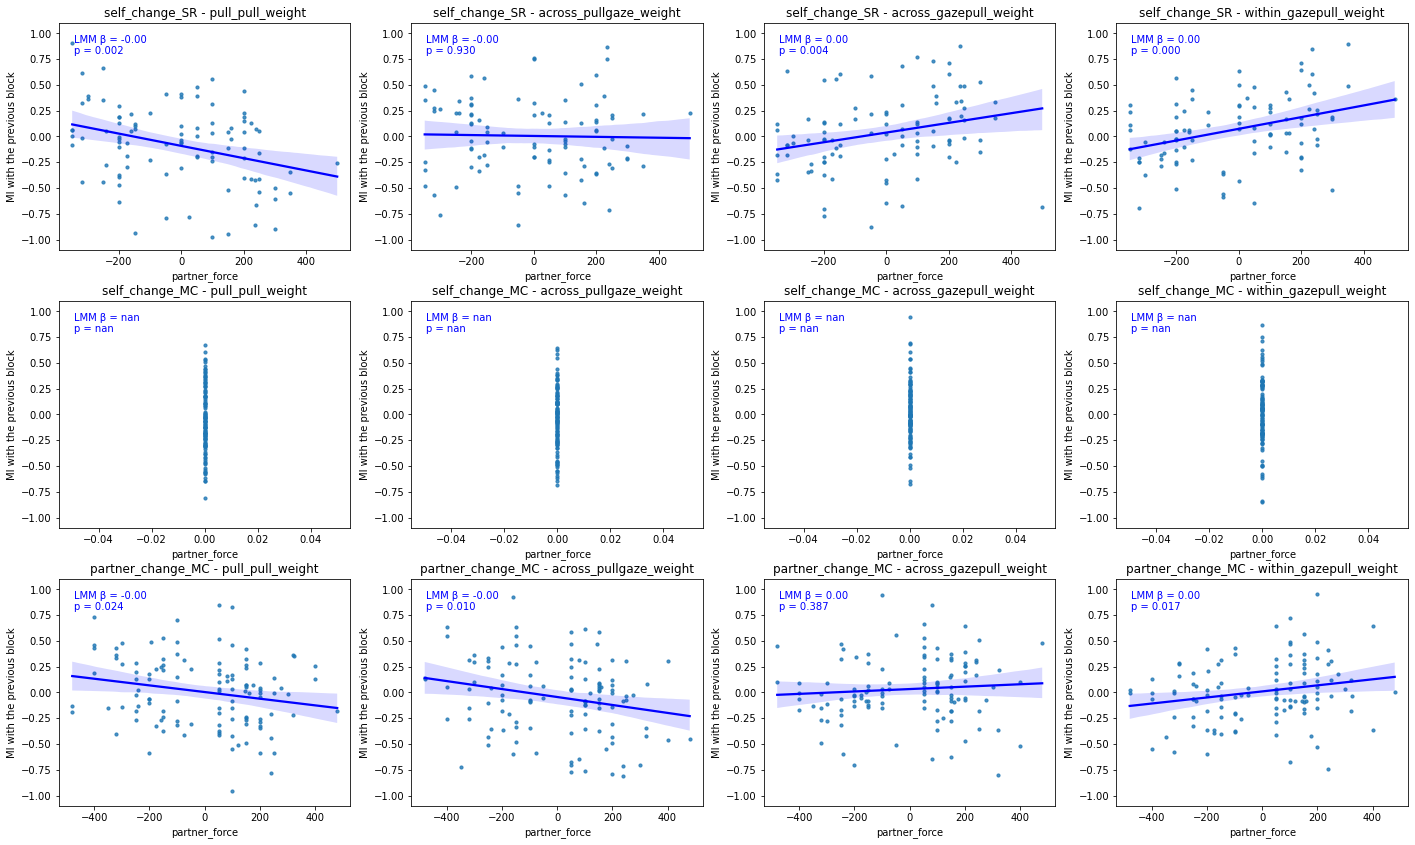

In [26]:
import statsmodels.formula.api as smf

# datatypename = 'quantile'
# summary_all_tgt = summary_all_results_quantile
datatypename = 'deltapreforce'
summary_all_tgt = summary_all_results_deltapreforce
# datatypename = 'norm_delta_partner_self_force'
# summary_all_tgt = summary_all_results


doblockIDregressed = 0
if doblockIDregressed:
    datatypename_prefix = 'blockIDregressed_'
else:
    datatypename_prefix = ''
    

nTrialConds = np.shape(np.unique(summary_all_tgt['forceContType']))[0]

# xplottype = 'succ_rate' # 'succ_rate', 'subblockID', 'gazenum_pers', 'pullnum_pers'
xplottype = 'partner_force'  # 'self_force', 'partner_force', 'norm_delta_partner_self_force'
yplottypes = ['pull_pull_weight','across_pullgaze_weight','across_gazepull_weight','within_gazepull_weight']
nyplottypes = np.shape(yplottypes)[0]

# Set up the figure grid
fig, axes = plt.subplots(nTrialConds, nyplottypes, 
                         figsize=(5 * nyplottypes, 4 * nTrialConds), 
                         sharex=False, sharey=False)
fig.tight_layout(pad=3.0)

# Plotting each unique condition and y-axis type
unique_conditions = summary_all_tgt['forceContType'].unique()

for i, condition in enumerate(unique_conditions):
    # Filter data for the current condition
    condition_data = summary_all_tgt[summary_all_tgt['forceContType'] == condition]
    
    for j, yplot in enumerate(yplottypes):
        ax = axes[i, j] if nTrialConds > 1 else axes[j]  # Adjust for single-row cases
        
        data_cleaned = condition_data[['date', 'self_animal', xplottype, 'subblockID', yplot]].reset_index(drop=True)
        data_cleaned['mean_weight'] = np.nan
        
        nrows = np.shape(data_cleaned)[0]
        for irow in np.arange(0,nrows,1):    
            tgt_weight = data_cleaned[yplot][irow][timelag_rowID].flatten()
            data_cleaned['mean_weight'][irow] = np.nanmean(tgt_weight)
        #
        data_cleaned = data_cleaned[~np.isnan(data_cleaned['mean_weight'])]
             
        if doblockIDregressed:
            data_cleaned = data_cleaned.reset_index(drop=True)
            data_cleaned['weight_resid'] = np.nan

            for this_date in data_cleaned['date'].unique():

                date_mask = data_cleaned['date'] == this_date
                date_data = data_cleaned.loc[date_mask]

                if len(date_data) > 1 and np.nanstd(date_data['subblockID']) > 0:

                    xxx = date_data['subblockID'].values
                    yyy = date_data['mean_weight'].values
                    valid = ~np.isnan(xxx) & ~np.isnan(yyy)

                    if np.sum(valid) > 1:
                        slope, intercept, _, _, _ = st.linregress(xxx[valid], yyy[valid])
                        yyy_res = yyy - (xxx * slope + intercept)
                        data_cleaned.loc[date_mask, 'weight_resid'] = yyy_res

            data_resid = data_cleaned[
                ~np.isnan(data_cleaned['weight_resid']) &
                ~np.isnan(data_cleaned[xplottype])
            ]

            seaborn.regplot(data=data_resid, x=xplottype, y='weight_resid', ax=ax,
                            scatter_kws={'s': 10}, line_kws={'color': 'blue'})

            # ---------- LMM: weight_resid ~ xplottype + (1|animal) ----------
            data_plot = data_resid.copy()
            data_plot = data_plot.rename(columns={
                'weight_resid': 'y',
                xplottype: 'x'
            })

            try:
                model = smf.mixedlm("y ~ x", data=data_plot, groups=data_plot["self_animal"])
                fit = model.fit(method='lbfgs', disp=False)

                beta = fit.params['x']
                p_value = fit.pvalues['x']

            except:
                beta = np.nan
                p_value = np.nan

            ax.text(0.05, 0.95,
                    f"LMM β = {beta:.2f}\np = {p_value:.3f}",
                    transform=ax.transAxes,
                    fontsize=10,
                    verticalalignment='top',
                    color='blue')
   
            
            
        else:
            # Create a regression plot for each y-axis type within the current condition
            seaborn.regplot(data=data_cleaned, x=xplottype, y='mean_weight', ax=ax, 
                            scatter_kws={'s': 10}, line_kws={'color': 'blue'})

            # ---------- LMM: mean_weight ~ xplottype + (1|animal) ----------

            data_plot = data_cleaned.copy()
            data_plot = data_plot.rename(columns={
                'mean_weight': 'y',
                xplottype: 'x'
            })

            try:
                model = smf.mixedlm("y ~ x", data=data_plot, groups=data_plot["self_animal"])
                fit = model.fit(method='lbfgs', disp=False)

                beta = fit.params['x']
                p_value = fit.pvalues['x']

            except:
                beta = np.nan
                p_value = np.nan

            ax.text(0.05, 0.95,
                    f"LMM β = {beta:.2f}\np = {p_value:.3f}",
                    transform=ax.transAxes,
                    fontsize=10,
                    verticalalignment='top',
                    color='blue')
        
        
        # Set titles and labels
        ax.set_title(f"{condition} - {yplot}")
        if i == nTrialConds - 1:
            ax.set_xlabel(xplottype)
        #
        ax.set_ylabel('mean weight')
        if doMI_firstblock:
            ax.set_ylabel('MI with the first block')
        if doMI_preblock:
            ax.set_ylabel('MI with the previous block')
        ax.set_ylim([-1.1,1.1])

plt.show()

savefigs = 1
if savefigs:
    figsavefolder = data_saved_folder+'figs_for_3LagDBN_and_bhv_singlecam_wholebodylabels_allsessions_basicEvents_allanimal_summary_DBNspecific/'+savefile_sufix+'/'+cameraID+'/'
    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)
    fig.savefig(figsavefolder+xplottype+"level_vs_"+timelag_tgt_name+
                "_DBNweight_allanimal_allcondition_versionof_"+datatypename_prefix+datatypename+".pdf")



#### do a AIC/BIC comparison to see which model works the best

In [ ]:
# =========================================
# DBN weight ~ force model comparison (AIC/BIC)
# with condition selector
# =========================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ===================== USER SETTINGS =====================

xplottype = 'self_force'   # 'self_force' or 'partner_force'

condition_to_use = 'self_change_MC'
# None → use all conditions pooled
# 'self_change_SR'
# 'self_change_MC'
# 'partner_change_MC'

timelag_rowID = timelag_rowID

yplottypes = [
    'pull_pull_weight',
    'across_pullgaze_weight',
    'across_gazepull_weight',
    'within_gazepull_weight'
]

force_dfs = {
    'raw': summary_all_results,
    'delta_prev': summary_all_results_deltapreforce,
    'delta_first': summary_all_results_deltafirstforce
}

# ========================================================

results_all = []

for yplot in yplottypes:

    for force_name, df in force_dfs.items():

        # ---------- condition selection ----------
        if condition_to_use is not None:
            df_use = df[df['forceContType'] == condition_to_use].copy()
        else:
            df_use = df.copy()

        # ---------- extract DBN mean weight ----------
        data = df_use[['subblockID', xplottype, yplot]].copy()

        mean_weight = []
        for val in data[yplot]:
            try:
                mean_weight.append(np.nanmean(val[timelag_rowID].flatten()))
            except:
                mean_weight.append(np.nan)

        data['mean_weight'] = mean_weight
        data = data.dropna(subset=['mean_weight', xplottype, 'subblockID'])

        if len(data) < 10:
            continue

        # ---------- baseline ----------
        model_block = smf.ols(
            "mean_weight ~ subblockID",
            data=data
        ).fit()

        # ---------- force model ----------
        model_force = smf.ols(
            f"mean_weight ~ {xplottype} + subblockID",
            data=data
        ).fit()

        results_all.append({
            'condition': condition_to_use if condition_to_use else 'all',
            'DBN_metric': yplot,
            'force_model': force_name,
            'xvar': xplottype,
            'n': len(data),

            'AIC_block_only': model_block.aic,
            'AIC_force+block': model_force.aic,
            'ΔAIC_force': model_force.aic - model_block.aic,

            'BIC_block_only': model_block.bic,
            'BIC_force+block': model_force.bic,
            'ΔBIC_force': model_force.bic - model_block.bic
        })

# ===================== RESULTS =====================

results_df = pd.DataFrame(results_all)
results_df = results_df.sort_values(['condition','DBN_metric','AIC_force+block'])

display(results_df)

print("\n🏆 Best force model per DBN metric (by AIC):")

display(
    results_df.loc[
        results_df.groupby(['condition','DBN_metric'])['AIC_force+block'].idxmin()
    ].sort_values(['condition','DBN_metric'])
)

#### average the DBN weights for different dependencies - plot each animal separately

In [ ]:
# datatypename = 'quantile'
# summary_all_tgt = summary_all_results_quantile
datatypename = 'deltapreforce'
summary_all_tgt = summary_all_results_deltapreforce

nTrialConds = np.shape(np.unique(summary_all_tgt['forceContType']))[0]

# xplottype = 'succ_rate' # 'succ_rate', 'subblockID', 'gazenum_pers', 'pullnum_pers'
xplottype = 'self_force'  # 'self_force', 'partner_force'
yplottypes = ['pull_pull_weight','across_pullgaze_weight','within_gazepull_weight']
nyplottypes = np.shape(yplottypes)[0]

animalcolors = ['red','blue','purple','darkblue','green','yellow']

# Set up the figure grid
fig, axes = plt.subplots(nTrialConds, nyplottypes, 
                         figsize=(5 * nyplottypes, 4 * nTrialConds), 
                         sharex=False, sharey=False)
fig.tight_layout(pad=3.0)

# Plotting each unique condition and y-axis type
unique_conditions = summary_all_tgt['forceContType'].unique()

for i, condition in enumerate(unique_conditions):
    # Filter data for the current condition
    condition_data = summary_all_tgt[summary_all_tgt['forceContType'] == condition]
    
    selfanimals = np.unique(condition_data['self_animal'])
    # selfanimals = ['kanga']
    nanimals = np.shape(selfanimals)[0]
    
    for ianimal in np.arange(0,nanimals,1):
        
        selfanimal = selfanimals[ianimal]
        
        condition_data_ianimal = condition_data[condition_data['self_animal']==selfanimal]
        
        for j, yplot in enumerate(yplottypes):
            ax = axes[i, j] if nTrialConds > 1 else axes[j]  # Adjust for single-row cases

            data_cleaned = condition_data_ianimal[[xplottype, yplot]].reset_index(drop=True)
            data_cleaned['mean_weight'] = np.nan

            nrows = np.shape(data_cleaned)[0]
            for irow in np.arange(0,nrows,1):    
                tgt_weight = data_cleaned[yplot][irow][timelag_rowID].flatten()
                data_cleaned['mean_weight'][irow] = np.nanmean(tgt_weight)
            #
            data_cleaned = data_cleaned[~np.isnan(data_cleaned['mean_weight'])]

            # Create a regression plot for each y-axis type within the current condition
            seaborn.regplot(data=data_cleaned, x=xplottype, y='mean_weight', ax=ax, 
                            scatter_kws={'s': 10, 'color': animalcolors[ianimal]}, 
                            line_kws={'color': animalcolors[ianimal]})

            try:
            # Calculate correlation coefficient and p-value
                r_value, p_value = st.pearsonr(data_cleaned[xplottype], data_cleaned['mean_weight'])
            except:
                r_value = np.nan
                p_value = np.nan

            # Add text for the correlation statistics
            ax.text(0.05, 0.95-0.1*ianimal, selfanimal+':'+f"r = {r_value:.2f}\np = {p_value:.3f}", 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top', color=animalcolors[ianimal])


            # Set titles and labels
            ax.set_title(f"{condition} - {yplot}")
            if i == nTrialConds - 1:
                ax.set_xlabel(xplottype)
            #
            ax.set_ylabel('mean weight')
            if doMI_firstblock:
                ax.set_ylabel('MI with the first block')
            if doMI_preblock:
                ax.set_ylabel('MI with the previous block')

plt.show()

savefigs = 1
if savefigs:
    figsavefolder = data_saved_folder+'figs_for_3LagDBN_and_bhv_singlecam_wholebodylabels_allsessions_basicEvents_allanimal_summary_DBNspecific/'+savefile_sufix+'/'+cameraID+'/'
    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)
    fig.savefig(figsavefolder+xplottype+"level_vs_"+timelag_tgt_name+"_DBNweight_separatedanimal_allcondition_versionof_"+datatypename+".pdf")



In [ ]:
datatypename = ''
summary_all_tgt = summary_all_results
# datatypename = 'deltafirstforce'
# summary_all_tgt = summary_all_results_deltafirstforce

nTrialConds = np.shape(np.unique(summary_all_tgt['forceContType']))[0]

xplottype = 'self_force' # 'self_focce' or 'other_force' or 'subblockID'
yplottypes = ['pull_pull_weight','across_pullgaze_weight','within_gazepull_weight']
nyplottypes = np.shape(yplottypes)[0]

animalcolors = ['red','blue','purple','darkblue','green','yellow']

slopes_all_result = pd.DataFrame(columns=['self_animal','date','tasktype','xplottype','yplottype','slope',])

# Set up the figure grid
fig, axes = plt.subplots(nTrialConds, nyplottypes, 
                         figsize=(5 * nyplottypes, 4 * nTrialConds), 
                         sharex=False, sharey=False)
fig.tight_layout(pad=3.0)

# Plotting each unique condition and y-axis type
unique_conditions = summary_all_tgt['forceContType'].unique()

for i, condition in enumerate(unique_conditions):
    # Filter data for the current condition
    condition_data = summary_all_tgt[summary_all_tgt['forceContType'] == condition]
    
    selfanimals = np.unique(condition_data['self_animal'])
    #  selfanimals = ['kanga']
    nanimals = np.shape(selfanimals)[0]
    
    for j, yplot in enumerate(yplottypes):
        ax = axes[i, j] if nTrialConds > 1 else axes[j]  # Adjust for single-row cases
            
        # plot for each animal separately
        for ianimal in np.arange(0,nanimals,1):

            selfanimal = selfanimals[ianimal]

            condition_data_ianimal = condition_data[condition_data['self_animal']==selfanimal]

            sessiondates = np.unique(condition_data_ianimal['date'])
            nsessiondates = np.shape(sessiondates)[0]

            for isessdate in np.arange(0,nsessiondates,1):

                sessiondate = sessiondates[isessdate]

                condition_data_ianimal_idate = condition_data_ianimal[condition_data_ianimal['date']==sessiondate]

                data_cleaned = condition_data_ianimal_idate[[xplottype, yplot]].reset_index(drop=True)
                data_cleaned['mean_weight'] = np.nan

                nrows = np.shape(data_cleaned)[0]
                for irow in np.arange(0,nrows,1):    
                    tgt_weight = data_cleaned[yplot][irow][timelag_rowID].flatten()
                    data_cleaned['mean_weight'][irow] = np.nanmean(tgt_weight)
                #
                data_cleaned = data_cleaned[~np.isnan(data_cleaned['mean_weight'])]
                
                # Create a regression plot for each y-axis type within the current condition
                seaborn.regplot(data=data_cleaned, x=xplottype, y='mean_weight', ax=ax, ci=None,
                                scatter_kws={'s':10,'color':'gray'}, 
                                line_kws={'color': animalcolors[ianimal],'linewidth': 1})

                try:
                    slope, intercept, r_value, p_value, std_err = st.linregress(data_cleaned[xplottype], 
                                                                                data_cleaned['mean_weight'])
                except:
                    slope = np.nan
                    
                slopes_all_result = slopes_all_result.append({'self_animal':selfanimal,
                                                              'date':sessiondate,
                                                              'tasktype':condition,
                                                              'xplottype':xplottype,
                                                              'yplottype':yplot,
                                                              'slope':slope}, ignore_index=True)
            
            # run wilcoxcon on the slope
            ind_slope_tgt = (slopes_all_result['self_animal']==selfanimal) &\
                            (slopes_all_result['tasktype']==condition) &\
                            (slopes_all_result['xplottype']==xplottype) &\
                            (slopes_all_result['yplottype']==yplot)
            slopes_tgt = slopes_all_result[ind_slope_tgt]
            slopes_tgt = slopes_tgt[~np.isnan(slopes_tgt['slope'])]
                            
            try:
                _,p_value = st.wilcoxon(slopes_tgt['slope'])
            except:
                p_value = np.nan 
                
            # Add text for the correlation statistics
            ax.text(0.05, 0.95-0.1*ianimal, selfanimal+':'+f"p = {p_value:.3f}", 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top', color=animalcolors[ianimal])

        
        # run wilcoxcon on the slope
        ind_slope_tgt = (slopes_all_result['tasktype']==condition) &\
                        (slopes_all_result['xplottype']==xplottype) &\
                        (slopes_all_result['yplottype']==yplot)
        slopes_tgt = slopes_all_result[ind_slope_tgt]
        slopes_tgt = slopes_tgt[~np.isnan(slopes_tgt['slope'])]
        
        try:
            _,p_value = st.wilcoxon(slopes_tgt['slope'])
        except:
            p_value = np.nan 
         
        # Add text for the correlation statistics
        ax.text(0.05, 0.95-0.1*nanimals, 'all animals:'+f"p = {p_value:.3f}", 
                transform=ax.transAxes, fontsize=10, verticalalignment='top', color='k')

        # Set titles and labels
        ax.set_title(f"{condition} - {yplot}")
        if i == nTrialConds - 1:
            ax.set_xlabel(xplottype)
        if j == 0:
            ax.set_ylabel(yplot)

plt.show()

savefigs = 1
if savefigs:
    figsavefolder = data_saved_folder+'figs_for_3LagDBN_and_bhv_singlecam_wholebodylabels_allsessions_basicEvents_allanimal_summary_DBNspecific/'+savefile_sufix+'/'+cameraID+'/'    
    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)
    fig.savefig(figsavefolder+xplottype+"level_vs_"+timelag_tgt_name+"_DBNweight_separatedanimal_separatedays_allcondition_versionof_"+datatypename+".pdf")



In [ ]:
aaa = slopes_all_result[(slopes_all_result['yplottype']=='pull_pull_weight')&\
                  (slopes_all_result['tasktype']=='self_change_MC')]
aaa = aaa[~np.isnan(aaa['slope'])]
aaa

In [ ]:
st.wilcoxon(aaa['slope'])